DATA ANALYSIS & VISUALISATION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import sys
import os

def load_dataset(file_path):
    df = pd.read_csv(file_path, low_memory=False)
    return df

In [2]:
sys.path.insert(0, os.path.abspath(".."))

## Analysis functions
# Netflix 
from scripts.analysis import netflix_rev_subs, netflix_spend, netflix_top_movies, netflix_top_shows
# Box Office - The Numbers
from scripts.analysis import worldwide_box_office_trend_by_genre, top_5_genres_percentage_per_year, top_8_genres_percentage_per_year, movie_count_per_distributor_overtime_top8, worldwide_box_office_trend_by_distributor
# TMDB
from scripts.analysis import tmdb_top_1000, popular_genres_top_1000, main_production_companies_top_1000, top20_movies_by_average_vote
# Awards
from scripts.analysis import oscars_winners_table, oscars_winners, total_oscar_wins_per_genre, oscar_wins_top_genres_per_decade, prep_oscars_wins, total_oscar_wins_per_production_company, oscar_wins_top_companies_per_decade


c:\Users\SANZ7884\OneDrive\Documents\Film-TV-Data-Analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load Merged datasets
#df_tmdb_imdb = load_dataset('../data/merged_data/merged_tmdb_imdb_ratings.csv') 
df_bafta_tmdb = load_dataset('../data/merged_data/merged_bafta_tmdb.csv')
df_oscar_tmdb = load_dataset('../data/merged_data/merged_oscar_tmdb.csv')
df_tmdb_box_office_mojo_the_numbers = load_dataset('../data/merged_data/merged_tmdb_box_office_mojo_the_numbers.csv')

# Load other datasets
df_netflix_revenue_subs_spend_c = load_dataset('../data/clean_data/cleaned_netflix_revenue_subs_spend.csv')
df_netflix_engagement_c = load_dataset('../data/clean_data/cleaned_netflix_engagement.csv')
# TMDB import
df_tmdb = load_dataset('../data/clean_data/cleaned_tmdb.csv')
# The Numbers import
df_the_numbers = load_dataset('../data/clean_data/cleaned_the_numbers.csv')

In [ ]:
df = df_oscar_tmdb

print(df.head(10).to_string(), flush=True)

# III -  Analysis

Note: think of correlation analysis I can do ! E.g. which factors influcence box office the most? Predicting awards, etc

In [ ]:
# Color palettes
# Categorical: tab10 , Set2, muted, deep
# Gradients: plasma , viridis , inferno , magma
# tip: add '_r' to any color palette to reverse the order (useful for gradients)

## III -  a. TMDB

Note: movies released between 1980 and 2025

Take top XXX movies (1000?) in terms of number of votes and vote average an analyse them - which genres are most popular, which production companies ere involved

Caveat: Movies have multiple genres and production companies assigned on TMDB

Thought: disregard TMDB's pupularity 

More analysis: analyse runtime per genre ? 

NEXT - SPLIT GENRE AND COMPANY GRAPHS BY ERA (1980-2000 / 2000-2015 / 2015 - 2025)

TABLEAU - Do similar visuals but with a slicer for release date

In [ ]:
df = df_tmdb

#print(df.head(10).to_string(), flush=True)

print(df_tmdb_top_1000.head(10).to_string(), flush=True)

# production companies: 'warner bros','20th century','marvel studios', 'paramount', 'universal','sony','disney','columbia pictures','legendary pictures','pixar','lionsgate','fox','dreamworks','miramax','new line cinema','mgm'
# Not added: a24 (only 5 in top 1000), dc comics (only 9 in top 1000), focus features, 'fox' (always part of 20th centure when being a movie studio, now part of Disney)

In [ ]:
# Get TMDb's top 1000 movies by vote_average, after a minimum vote_count filter of 1000 votes
# includes genre categorisation by the following main genres:
# genres: action, science fiction, comedy, drama, adventure, thriller, fantasy, romance, crime, animation, family, horror, western

df_tmdb_top_1000 = tmdb_top_1000(df_tmdb)

popular_genres_top_1000(df_tmdb_top_1000)

In [ ]:
main_production_companies_top_1000(df_tmdb_top_1000)

In [ ]:
# Top 20 movie titles by average vote in the filtered df_top dataset

df_tmdb_top_1000 = tmdb_top_1000(df_tmdb)

## 1980-1999
#start_year = 1980
#end_year = 1999

## 2000-2014
start_year = 2000
end_year = 2014

## 2015-2025
#start_year = 2015
#end_year = 2025

top20_movies_by_average_vote(df_tmdb_top_1000, start_year, end_year)

## III -  b. Box Office

Note: using The Numbers top XX movies in Box Office revenue betwewen 2015 and 2025.

Also - calculate other figures to answer questions such as 
- Which distributor has the highest number of movies in the top 100 from 2015 and 2025
 Which distributor has the highest average worldwide box office in the top 100 from 2015 and 2025

In [ ]:
df = df_the_numbers
print(df.head(10).to_string(), flush=True)

## Inflation adjusted - Domestic Box Office
# Top titles 
# Top genres

## Worldwide Box Office
# against budget

# top 3 titles per year (use rank column) - TABLEAU ?

## Source analysis

## Production Budget - over time and compared to the revenue trend
# Revenue - Budget to get an estimate of the profit ?
# International vs Domestic Box office ? although many of the titles in the dataset are US releases, but not all so hard to draw conclusions

## More advanced - model that predicts box office (or rank) based on the other features - regression model ?

## More advance Data Science ? Add trend / forecasting ?

In [ ]:
# count of movies in per theatrical distributor per year - bar chart - top 8

movie_count_per_distributor_overtime_top8(df_the_numbers)

In [ ]:
# worldwide box office per theatrical distributor (top 5) - line chart 

worldwide_box_office_trend_by_distributor(df_the_numbers)

In [ ]:
worldwide_box_office_trend_by_genre(df_the_numbers)

In [ ]:
top_5_genres_percentage_per_year(df_the_numbers)

# Caveat - percentages of movies for those 5 genres only, not the other genres. Write in markdown the names of the less popular genres?

In [ ]:
top_8_genres_percentage_per_year(df_the_numbers)

# Caveat - percentages of movies for those 5 genres only, not the other genres. Write in markdown the names of the less popular genres?

## III -  c. Awards - The Oscars

Filtering for ceremonies since 1980.

Notes:
- Focus on Winners only to make it easier
- When I have more time - can also analyse nominated ones e.g. which genres often don't get the win
- Could do actors with the most nominations and / or wins

In [ ]:
df = df_oscar_tmdb.sort_values("Year",ascending=False)

print(df.head(10).to_string(), flush=True)

In [ ]:
# Winners per year

year = 2020 # Select a year

df = df_oscar_tmdb.copy()

winners = oscars_winners(df,year)
oscars_winners_table(winners, year)

In [ ]:
# Genres with the most wins

df = df_oscar_tmdb.copy()
total_oscar_wins_per_genre(df)

# Note: if a movie has multiple genres associated to it, it will be counted for both genres

In [ ]:
# Genres with the most wins PER DECADE

df = df_oscar_tmdb.copy()
oscar_wins_top_genres_per_decade(df,top_n=4)

In [ ]:
# Production Companies with the most wins

df = df_oscar_tmdb.copy()

total_oscar_wins_per_production_company(df)

# note: if an oscar is associated to multiple production companies it will still count for each of them, not just once

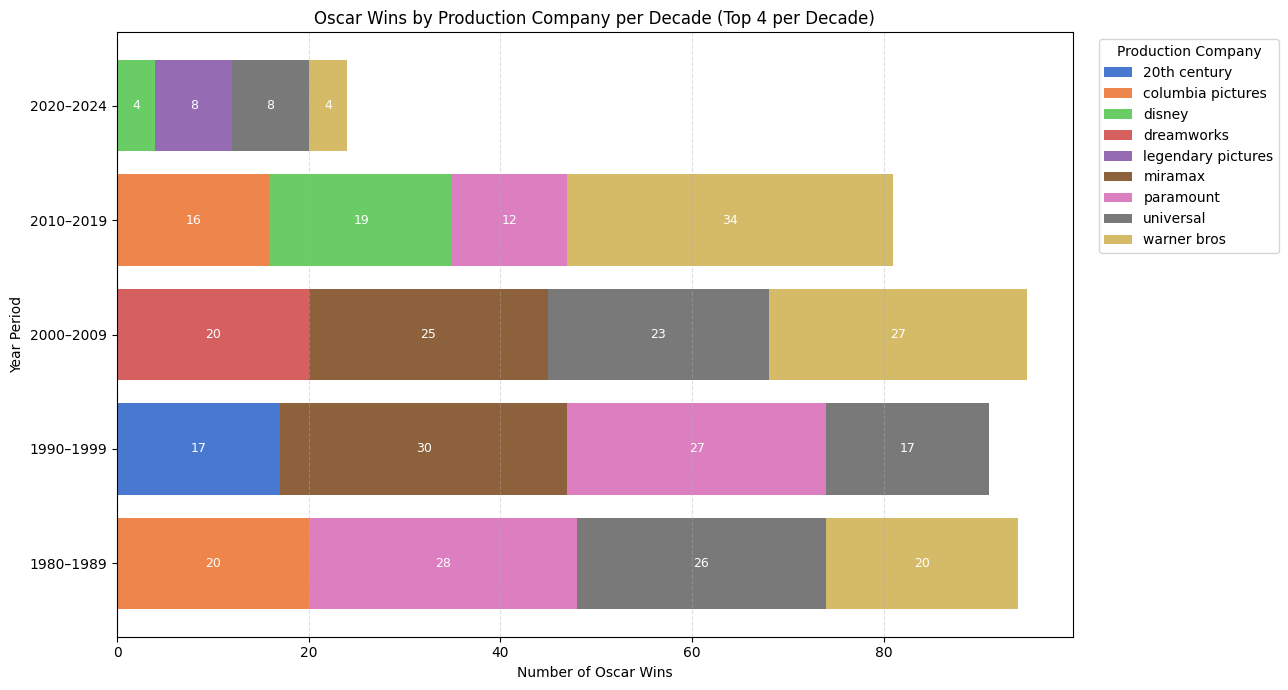

In [ ]:
# Production Companies with the most wins PER DECADE

df = df_oscar_tmdb.copy()

oscar_wins_top_companies_per_decade(df,top_n=4)

In [ ]:
# NOT MATCHING ROWS - ANALYSIS
df = df_oscar_tmdb

df_no_match = df[df['_merge'] != 'both']
df_no_match_films = df_no_match.value_counts('Film')
print(df_no_match_films.head(20).to_string(), flush=True)
#len(df_no_match)

mask = df_tmdb['title'].str.contains('titanic', case=False, na=False)
if mask.any():
    print(df_tmdb[mask])
else:
    print('no match')

## III - d . Netflix data

In [ ]:
df = df_netflix_revenue_subs_spend_c.copy()

# Print top rows
print(df.head(10).to_string(), flush=True)

In [ ]:
## Netflix Revenue and Subscribers over time

netflix_rev_subs(df_netflix_revenue_subs_spend_c)

In [ ]:
# Netflix Content Spend over time

netflix_spend(df_netflix_revenue_subs_spend_c)

In [ ]:
# Netflic Engagement over time

df = df_netflix_engagement_c.copy()

df_movies = df[df['Type'] == 'Movie']
df_shows = df[df['Type'] == 'TV']

# Print top rows
print(df.head(10).to_string(), flush=True)

# Questions to explore:
# For movies only? Compare number of views between movies and TV shows
# Biggest titles by engagement - number of hours and number of views
# Divide Runtime into buckets and compare engagement by views (notes: for movies only)
# Compare average overall hours and views by year.

In [ ]:
netflix_top_shows(df_netflix_engagement_c)

In [ ]:

netflix_top_movies(df_netflix_engagement_c)

# Discarded / Unsure

In [ ]:
# View distribution of a column

# Histograms: sns.histplot(df['column_name'], bins= XX)

# Boxplots: sns.boxplot(df['column_name'])

# Correlation: df.corr() and sns.heatmap(df.corr(), annot=True)

In [ ]:
# Look for patterns

# Ideas:

# sns.barplot(x='Year',y='Netflix Subscribers',data=df)

# sns.scatterplot(x='ratings',y='box_office',data=df)

sns.lineplot(x='Year',y='Netflix Revenue',data=df)

plt.show()

## TMDB

In [ ]:
# UNSURE OF WHETHER TO KEEP

# PRODUCTION COMPANIES 
# Bar chart showing count of the top 1000 movies, split by primary genre with legend

df_tmdb_top_1000 = tmdb_top_1000(df_tmdb)

# Production companies of interest
production_companies = ['warner bros','metro-goldwyn-mayer', '20th century', 'marvel studios', 'paramount', 'universal','sony','disney','columbia pictures','legendary pictures','pixar','lionsgate','dreamworks','miramax','new line cinema']

# Melt the data to long format for aggregation (one row per movie-production_company pair)
df_melted = df_tmdb_top_1000.melt(id_vars=['vote_count', 'vote_average'], value_vars=production_companies, var_name='production_company', value_name='present')
df_melted = df_melted[df_melted['present'] == 1].drop(columns='present')  # Keep only present production companies

# Aggregate per production company
company_stats = df_melted.groupby('production_company').agg(
    avg_vote_average=('vote_average', 'mean'),
    movie_count=('production_company', 'size'),
    total_vote_count=('vote_count', 'sum')).reset_index()

# Sort by total_vote_count descending for the chart
company_stats_sorted = company_stats.sort_values('movie_count', ascending=False)
print(company_stats.to_string(index=False))

genres_of_interest = ['action', 'science fiction','adventure','drama', 'thriller','romance','fantasy', 'comedy', 'horror','animation']

def primary_genre(row):
    for genre in genres_of_interest:
        if row.get(genre, 0) == 1:
            return genre
    return 'other'

df_tmdb_top_1000['primary_genre'] = df_tmdb_top_1000.apply(primary_genre, axis=1)

palette_keys = genres_of_interest + ['other']
genre_company_counts = pd.DataFrame(index=company_stats_sorted['production_company'])

for genre in palette_keys:
    genre_company_counts[genre] = [df_tmdb_top_1000[(df_tmdb_top_1000[comp] == 1) & (df_tmdb_top_1000['primary_genre'] == genre)].shape[0] for comp in company_stats_sorted['production_company']]

fig, ax = plt.subplots(figsize=(12, 8))
bottom = np.zeros(len(company_stats_sorted))
colors = sns.color_palette('tab20', len(palette_keys))

for i, genre in enumerate(palette_keys):
    values = genre_company_counts.loc[company_stats_sorted['production_company'], genre]
    ax.bar(range(len(company_stats_sorted)), values, bottom=bottom, label=genre, color=colors[i])
    bottom += values

ax.set_xticks(range(len(company_stats_sorted)))
ax.set_xticklabels(company_stats_sorted['production_company'], rotation=45, ha='right')
ax.set_title('Most Popular Production Companies by Number of Movies in Top 1000, Split by Primary Genre')
ax.set_xlabel('Production Company')
ax.set_ylabel('Number of Movies')
ax.legend(title='Primary Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)
fig.tight_layout()
plt.show()

# Optional: Print the aggregated data for reference
print(company_stats_sorted.to_string(index=False))

In [ ]:
# DON'T LIKE THIS ONE - DISCARD
# TMDB
# Bar chart for average vote average per production company

company_stats_sorted = company_stats.sort_values('avg_vote_average', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 8))
positions = range(len(company_stats_sorted))
bars = ax.bar(positions, company_stats_sorted['avg_vote_average'], color=sns.color_palette('coolwarm', len(company_stats_sorted)))
ax.set_xticks(positions)
ax.set_xticklabels(company_stats_sorted['production_company'], rotation=45, ha='right')
ax.set_title('Average Vote Average by Production Company in Top 1000 Movies')
ax.set_xlabel('Production Company')
ax.set_ylabel('Average Vote Average (/10)')
ax.set_ylim(0, company_stats_sorted['avg_vote_average'].max() * 1.1)

ax.grid(axis='y', linestyle='--', alpha=0.4)
fig.tight_layout()
plt.show()

# Optional: Print the aggregated data for reference
print(company_stats_sorted[['production_company', 'avg_vote_average', 'movie_count']].to_string(index=False))

In [ ]:
#tests tmdb - boxplot of vote counts - not needed anymore
df = df_tmdb.copy()
df_above1000_votes = df[df['vote_count'] > 1000]
print(len(df_above1000_votes))
df= df_above1000_votes
vote_counts = df['vote_count'].dropna()
q1 = vote_counts.quantile(0.25)
median = vote_counts.median()
q3 = vote_counts.quantile(0.75)
mean = vote_counts.mean()
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x=vote_counts, showmeans=True,
                 meanprops={"marker":"D", "markeredgecolor":"black", "markerfacecolor":"white"},
                 medianprops={"color": "red"})
plt.title('Vote Count Distribution for All TMDB Movies')
plt.xlabel('Vote Count')
plt.ylabel('')
for value, color, label in [(q1, 'blue', 'Q1'),(median, 'red', 'Median'),(q3, 'blue', 'Q3'),
    (mean, 'green', 'Mean')]:
    ax.axvline(value, color=color, linestyle='--', linewidth=1.5, alpha=0.8)
    ax.text(value, 0.12, f'{label}\n{value:,.0f}', rotation=90, ha='center', va='bottom', color=color,
            transform=ax.get_xaxis_transform(), fontsize=9)
plt.tight_layout()
plt.show()
print('Vote count summary for full dataset:')
print(vote_counts.describe())

#print(df_above1000_votes.sort_values('vote_average', ascending=False).head(20).to_string(), flush=True)
